  stormname                time   lat   lon
0    HELENE 2024-09-26 00:00:00  22.8 -86.7
1    HELENE 2024-09-26 06:00:00  23.6 -86.5
2    HELENE 2024-09-26 12:00:00  24.7 -85.9
3    HELENE 2024-09-26 18:00:00  26.7 -84.9
4    HELENE 2024-09-27 00:00:00  28.7 -84.3
         model  Hs_mean_center  Hs_max_center  Area_mean_km2_center  \
0  ADCIRC/SWAN        9.068947       9.781714          37793.790118   
1   COAWST/WW3        8.384593      10.472296          38844.277292   
2    HurryWave        8.522560       9.836518          40192.275590   

   Hs_mean_touch  Hs_max_touch  Area_mean_km2_touch  \
0       8.983894      9.598159         44175.938823   
1       8.369830     10.444937         39837.356981   
2       8.493856      9.836518         40951.464153   

   Hs_mean_diff_touch_minus_center  Area_mean_ratio_touch_over_center  
0                        -0.085053                           1.168868  
1                        -0.014763                           1.025566  
2             

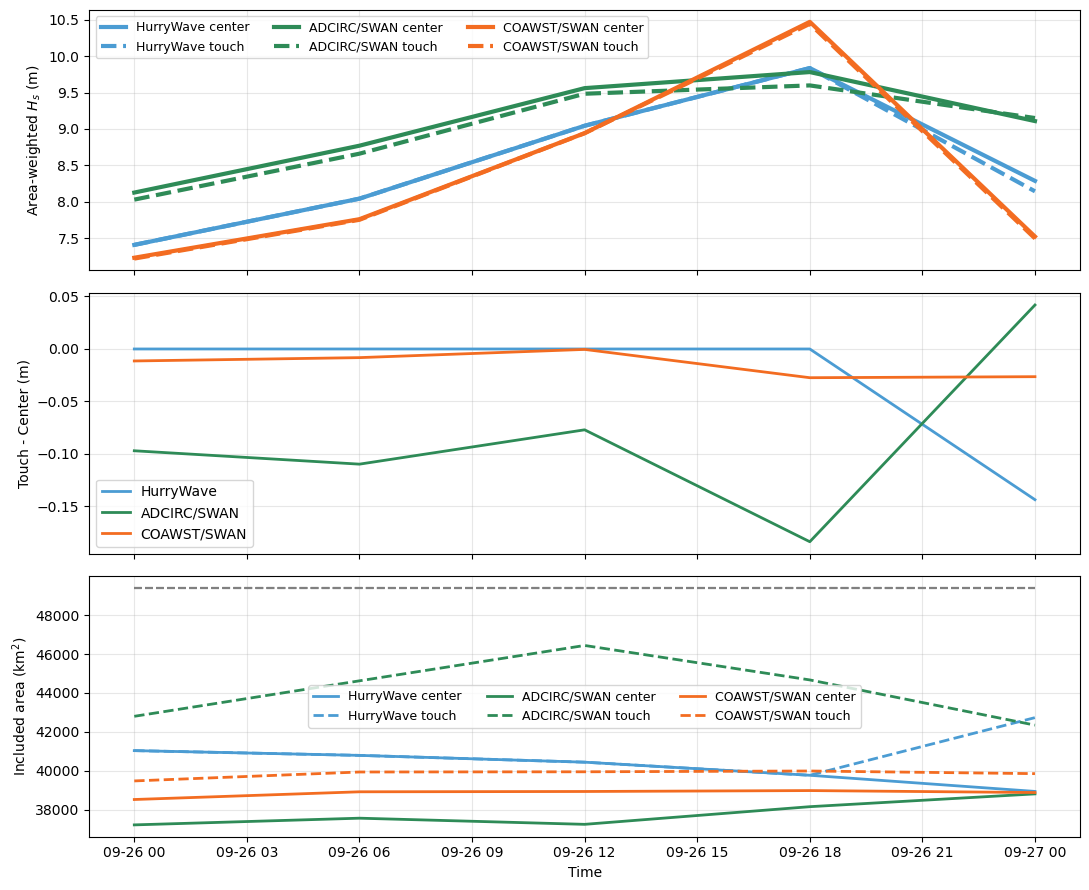

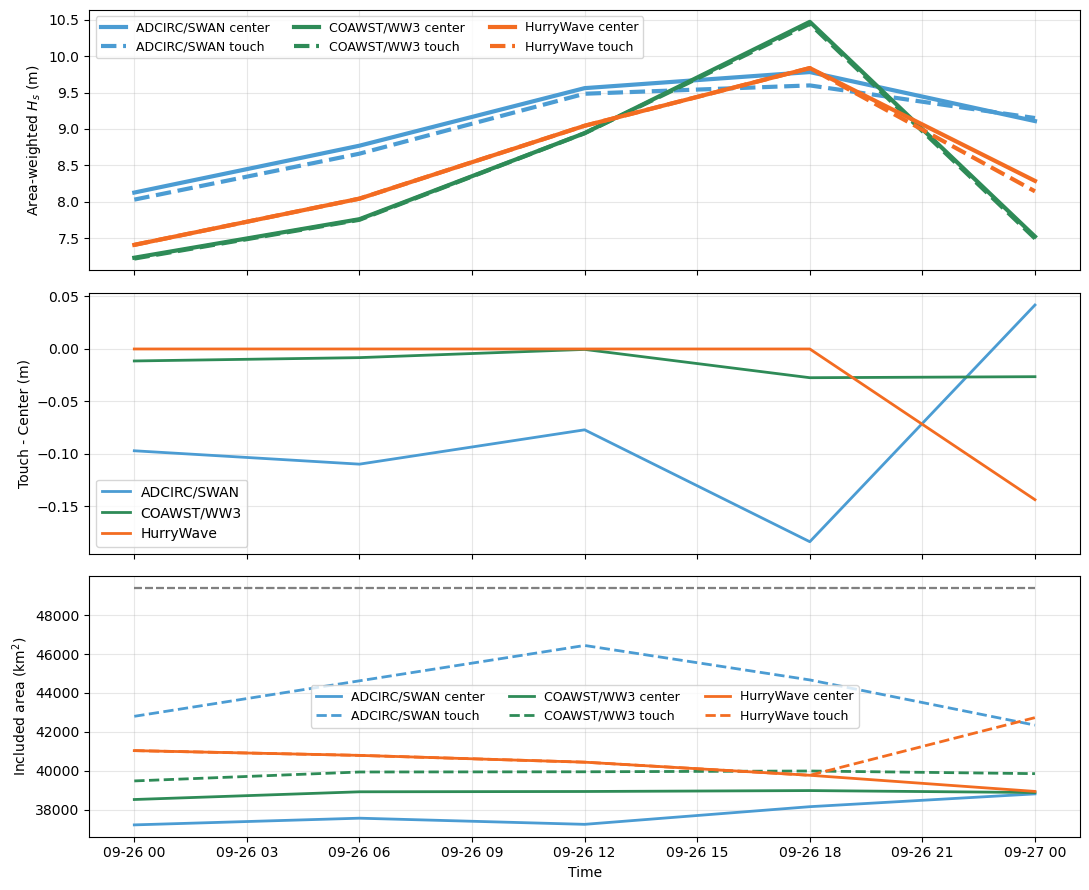

In [47]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

#Colors
usgs_green = '#2E8B57'
dutch_orange = '#F36C21'
unc_blue = '#4B9CD3'

# ============================================================
# CONSTANTS
# ============================================================
EARTH_RADIUS_M = 6371000.0
NM_TO_M = 1852.0

# ============================================================
# BASIC GEOMETRY
# ============================================================
def square_side_from_radius_nm(radius_nm):
    r_m = radius_nm * NM_TO_M
    return np.sqrt(np.pi) * r_m


def lonlat_to_xy_local_m(lon, lat, lon0, lat0):
    lon = np.asarray(lon, dtype=float)
    lat = np.asarray(lat, dtype=float)
    x = np.deg2rad(lon - lon0) * EARTH_RADIUS_M * np.cos(np.deg2rad(lat0))
    y = np.deg2rad(lat - lat0) * EARTH_RADIUS_M
    return x, y


def polygon_area_m2(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return 0.5 * np.abs(np.sum(x * np.roll(y, -1) - y * np.roll(x, -1)))


# ============================================================
# POLYGON / BOX INTERSECTION TESTS
# ============================================================
def point_in_box(x, y, xmin, xmax, ymin, ymax):
    return (x >= xmin) & (x <= xmax) & (y >= ymin) & (y <= ymax)


def segment_intersects_segment(p1, p2, q1, q2):
    def orient(a, b, c):
        return (b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0])

    def on_segment(a, b, c):
        return (min(a[0], b[0]) <= c[0] <= max(a[0], b[0]) and
                min(a[1], b[1]) <= c[1] <= max(a[1], b[1]))

    o1 = orient(p1, p2, q1)
    o2 = orient(p1, p2, q2)
    o3 = orient(q1, q2, p1)
    o4 = orient(q1, q2, p2)

    if ((o1 > 0 and o2 < 0) or (o1 < 0 and o2 > 0)) and \
       ((o3 > 0 and o4 < 0) or (o3 < 0 and o4 > 0)):
        return True

    eps = 1e-12
    if abs(o1) < eps and on_segment(p1, p2, q1):
        return True
    if abs(o2) < eps and on_segment(p1, p2, q2):
        return True
    if abs(o3) < eps and on_segment(q1, q2, p1):
        return True
    if abs(o4) < eps and on_segment(q1, q2, p2):
        return True

    return False


def point_in_polygon(x, y, poly_x, poly_y):
    inside = False
    n = len(poly_x)
    j = n - 1
    for i in range(n):
        xi, yi = poly_x[i], poly_y[i]
        xj, yj = poly_x[j], poly_y[j]
        cond = ((yi > y) != (yj > y))
        if cond:
            xint = (xj - xi) * (y - yi) / (yj - yi + 1e-30) + xi
            if x < xint:
                inside = not inside
        j = i
    return inside


def polygon_intersects_box(poly_x, poly_y, xmin, xmax, ymin, ymax):
    poly_x = np.asarray(poly_x, dtype=float)
    poly_y = np.asarray(poly_y, dtype=float)

    inside_v = ((poly_x >= xmin) & (poly_x <= xmax) &
                (poly_y >= ymin) & (poly_y <= ymax))
    if np.any(inside_v):
        return True

    box_pts = [(xmin, ymin), (xmax, ymin), (xmax, ymax), (xmin, ymax)]
    for bx, by in box_pts:
        if point_in_polygon(bx, by, poly_x, poly_y):
            return True

    poly_pts = list(zip(poly_x, poly_y))
    poly_edges = list(zip(poly_pts, poly_pts[1:] + poly_pts[:1]))
    box_edges = [
        ((xmin, ymin), (xmax, ymin)),
        ((xmax, ymin), (xmax, ymax)),
        ((xmax, ymax), (xmin, ymax)),
        ((xmin, ymax), (xmin, ymin)),
    ]

    for e1 in poly_edges:
        for e2 in box_edges:
            if segment_intersects_segment(e1[0], e1[1], e2[0], e2[1]):
                return True

    return False


# ============================================================
# STRUCTURED GRID AREAS / POLYGONS
# ============================================================
def rho_cell_area_from_pm_pn(pm, pn):
    pm = np.asarray(pm, dtype=float)
    pn = np.asarray(pn, dtype=float)
    return 1.0 / (pm * pn)


def structured_cell_polygons_curvilinear(lon2d, lat2d, lon0, lat0):
    lon2d = np.asarray(lon2d, dtype=float)
    lat2d = np.asarray(lat2d, dtype=float)

    x2d, y2d = lonlat_to_xy_local_m(lon2d, lat2d, lon0, lat0)
    ny, nx = x2d.shape

    xpoly = np.full((ny, nx, 4), np.nan)
    ypoly = np.full((ny, nx, 4), np.nan)

    for j in range(1, ny - 1):
        for i in range(1, nx - 1):
            xcorn = np.array([
                0.25 * (x2d[j-1, i-1] + x2d[j-1, i]   + x2d[j, i-1]   + x2d[j, i]),
                0.25 * (x2d[j-1, i]   + x2d[j-1, i+1] + x2d[j, i]     + x2d[j, i+1]),
                0.25 * (x2d[j, i]     + x2d[j, i+1]   + x2d[j+1, i]   + x2d[j+1, i+1]),
                0.25 * (x2d[j, i-1]   + x2d[j, i]     + x2d[j+1, i-1] + x2d[j+1, i]),
            ])
            ycorn = np.array([
                0.25 * (y2d[j-1, i-1] + y2d[j-1, i]   + y2d[j, i-1]   + y2d[j, i]),
                0.25 * (y2d[j-1, i]   + y2d[j-1, i+1] + y2d[j, i]     + y2d[j, i+1]),
                0.25 * (y2d[j, i]     + y2d[j, i+1]   + y2d[j+1, i]   + y2d[j+1, i+1]),
                0.25 * (y2d[j, i-1]   + y2d[j, i]     + y2d[j+1, i-1] + y2d[j+1, i]),
            ])
            xpoly[j, i, :] = xcorn
            ypoly[j, i, :] = ycorn

    xpoly[0, :, :] = xpoly[1, :, :]
    xpoly[-1, :, :] = xpoly[-2, :, :]
    xpoly[:, 0, :] = xpoly[:, 1, :]
    xpoly[:, -1, :] = xpoly[:, -2, :]

    ypoly[0, :, :] = ypoly[1, :, :]
    ypoly[-1, :, :] = ypoly[-2, :, :]
    ypoly[:, 0, :] = ypoly[:, 1, :]
    ypoly[:, -1, :] = ypoly[:, -2, :]

    return xpoly, ypoly


def structured_cell_polygons_from_corners(corner_x, corner_y, lon0, lat0):
    corner_x = np.asarray(corner_x, dtype=float)
    corner_y = np.asarray(corner_y, dtype=float)

    ny = corner_x.shape[0] - 1
    nx = corner_x.shape[1] - 1

    xpoly = np.full((ny, nx, 4), np.nan)
    ypoly = np.full((ny, nx, 4), np.nan)

    for j in range(ny):
        for i in range(nx):
            lons = np.array([
                corner_x[j, i],
                corner_x[j, i+1],
                corner_x[j+1, i+1],
                corner_x[j+1, i],
            ])
            lats = np.array([
                corner_y[j, i],
                corner_y[j, i+1],
                corner_y[j+1, i+1],
                corner_y[j+1, i],
            ])
            x, y = lonlat_to_xy_local_m(lons, lats, lon0, lat0)
            xpoly[j, i, :] = x
            ypoly[j, i, :] = y

    return xpoly, ypoly


# ============================================================
# UNSTRUCTURED TRIANGLE / NODE AREAS
# ============================================================
def triangle_areas_m2(x, y, tri):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    tri = np.asarray(tri, dtype=int)

    x1 = x[tri[:, 0]]
    y1 = y[tri[:, 0]]
    x2 = x[tri[:, 1]]
    y2 = y[tri[:, 1]]
    x3 = x[tri[:, 2]]
    y3 = y[tri[:, 2]]

    return 0.5 * np.abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))


def nodal_areas_from_triangles(x, y, tri):
    atri = triangle_areas_m2(x, y, tri)
    anode = np.zeros_like(x, dtype=float)
    for k in range(3):
        np.add.at(anode, tri[:, k], atri / 3.0)
    return anode


def build_node_to_triangles(tri, nnode):
    node_to_tri = defaultdict(list)
    for itri, nodes in enumerate(np.asarray(tri, dtype=int)):
        for n in nodes:
            node_to_tri[n].append(itri)
    return node_to_tri


# ============================================================
# BOX MASKS
# ============================================================
def structured_masks_center_and_touch(x_center, y_center, xpoly, ypoly, side_m):
    half = 0.5 * side_m
    xmin, xmax = -half, half
    ymin, ymax = -half, half

    mask_center = point_in_box(x_center, y_center, xmin, xmax, ymin, ymax)

    ny, nx = x_center.shape
    mask_touch = np.zeros((ny, nx), dtype=bool)

    for j in range(ny):
        for i in range(nx):
            mask_touch[j, i] = polygon_intersects_box(
                xpoly[j, i, :], ypoly[j, i, :], xmin, xmax, ymin, ymax
            )

    return mask_center, mask_touch


def unstructured_masks_center_and_touch(x_node, y_node, tri, node_to_tri, side_m):
    half = 0.5 * side_m
    xmin, xmax = -half, half
    ymin, ymax = -half, half

    mask_center = point_in_box(x_node, y_node, xmin, xmax, ymin, ymax)

    tri = np.asarray(tri, dtype=int)
    nnode = x_node.size
    ntri = tri.shape[0]

    tri_touch = np.zeros(ntri, dtype=bool)
    for itri in range(ntri):
        nodes = tri[itri]
        tri_touch[itri] = polygon_intersects_box(
            x_node[nodes], y_node[nodes], xmin, xmax, ymin, ymax
        )

    mask_touch = np.zeros(nnode, dtype=bool)
    for inode in range(nnode):
        adj = node_to_tri.get(inode, [])
        if len(adj):
            mask_touch[inode] = np.any(tri_touch[adj])

    return mask_center, mask_touch


# ============================================================
# AREA-WEIGHTED METRICS
# ============================================================
def weighted_metrics_from_mask(hs, area, mask):
    valid = np.isfinite(hs) & np.isfinite(area) & (area > 0.0) & mask
    if not np.any(valid):
        return np.nan, np.nan, np.nan, 0.0, 0

    w = area[valid]
    h = hs[valid]

    hs_mean = np.sum(h * w) / np.sum(w)
    hs2_mean = np.sum((h**2) * w) / np.sum(w)
    hs_rms_equiv = np.sqrt(hs2_mean)
    area_sum = np.sum(w)
    npts = np.count_nonzero(valid)

    return hs_mean, hs2_mean, hs_rms_equiv, area_sum, npts


# ============================================================
# MODEL DRIVERS
# ============================================================
def compute_metrics_square_coawst(
    hs,
    lon_rho,
    lat_rho,
    pm,
    pn,
    storm_lon,
    storm_lat,
    radius_nm=60.0,
    time=None,
    model_name="COAWST",
):
    hs = np.asarray(hs, dtype=float)
    lon_rho = np.asarray(lon_rho, dtype=float)
    lat_rho = np.asarray(lat_rho, dtype=float)
    area = rho_cell_area_from_pm_pn(pm, pn)

    nt = hs.shape[0]
    side_m = square_side_from_radius_nm(radius_nm)

    out = {k: np.full(nt, np.nan) for k in [
        "hs_area_mean_center", "hs2_area_mean_center", "hs_rms_equiv_center", "area_sum_m2_center",
        "hs_area_mean_touch",  "hs2_area_mean_touch",  "hs_rms_equiv_touch",  "area_sum_m2_touch",
    ]}
    out["npts_center"] = np.full(nt, 0, dtype=int)
    out["npts_touch"] = np.full(nt, 0, dtype=int)

    for it in range(nt):
        lon0 = storm_lon[it]
        lat0 = storm_lat[it]

        x_center, y_center = lonlat_to_xy_local_m(lon_rho, lat_rho, lon0, lat0)
        xpoly, ypoly = structured_cell_polygons_curvilinear(lon_rho, lat_rho, lon0, lat0)
        mask_center, mask_touch = structured_masks_center_and_touch(x_center, y_center, xpoly, ypoly, side_m)

        vals = weighted_metrics_from_mask(hs[it], area, mask_center)
        out["hs_area_mean_center"][it], out["hs2_area_mean_center"][it], out["hs_rms_equiv_center"][it], out["area_sum_m2_center"][it], out["npts_center"][it] = vals

        vals = weighted_metrics_from_mask(hs[it], area, mask_touch)
        out["hs_area_mean_touch"][it], out["hs2_area_mean_touch"][it], out["hs_rms_equiv_touch"][it], out["area_sum_m2_touch"][it], out["npts_touch"][it] = vals

    coords = {"time": pd.to_datetime(time) if time is not None else np.arange(nt)}
    ds = xr.Dataset({k: ("time", v) for k, v in out.items()}, coords=coords)
    ds["storm_lon"] = ("time", storm_lon)
    ds["storm_lat"] = ("time", storm_lat)
    ds.attrs.update(dict(model_name=model_name, region_shape="square", radius_nm=radius_nm, square_side_m=side_m))
    return ds


def compute_metrics_square_hurrywave(
    hs,
    x_center_ll,
    y_center_ll,
    corner_x_ll,
    corner_y_ll,
    storm_lon,
    storm_lat,
    radius_nm=60.0,
    time=None,
    model_name="HurryWave",
    mask=None,
):
    hs = np.asarray(hs, dtype=float)
    x_center_ll = np.asarray(x_center_ll, dtype=float)
    y_center_ll = np.asarray(y_center_ll, dtype=float)
    corner_x_ll = np.asarray(corner_x_ll, dtype=float)
    corner_y_ll = np.asarray(corner_y_ll, dtype=float)
    storm_lon = np.asarray(storm_lon, dtype=float)
    storm_lat = np.asarray(storm_lat, dtype=float)

    if mask is not None:
        mask = np.asarray(mask).astype(bool)

    nt = hs.shape[0]
    side_m = square_side_from_radius_nm(radius_nm)

    out = {k: np.full(nt, np.nan) for k in [
        "hs_area_mean_center", "hs2_area_mean_center", "hs_rms_equiv_center", "area_sum_m2_center",
        "hs_area_mean_touch",  "hs2_area_mean_touch",  "hs_rms_equiv_touch",  "area_sum_m2_touch",
    ]}
    out["npts_center"] = np.full(nt, 0, dtype=int)
    out["npts_touch"] = np.full(nt, 0, dtype=int)

    for it in range(nt):
        lon0 = storm_lon[it]
        lat0 = storm_lat[it]

        x_center, y_center = lonlat_to_xy_local_m(x_center_ll, y_center_ll, lon0, lat0)
        xpoly, ypoly = structured_cell_polygons_from_corners(corner_x_ll, corner_y_ll, lon0, lat0)

        area_it = np.full(x_center.shape, np.nan)
        ny, nx = x_center.shape
        for j in range(ny):
            for i in range(nx):
                area_it[j, i] = polygon_area_m2(xpoly[j, i, :], ypoly[j, i, :])

        mask_center, mask_touch = structured_masks_center_and_touch(x_center, y_center, xpoly, ypoly, side_m)

        if mask is not None:
            mask_center = mask_center & mask
            mask_touch = mask_touch & mask

        vals = weighted_metrics_from_mask(hs[it], area_it, mask_center)
        out["hs_area_mean_center"][it], out["hs2_area_mean_center"][it], out["hs_rms_equiv_center"][it], out["area_sum_m2_center"][it], out["npts_center"][it] = vals

        vals = weighted_metrics_from_mask(hs[it], area_it, mask_touch)
        out["hs_area_mean_touch"][it], out["hs2_area_mean_touch"][it], out["hs_rms_equiv_touch"][it], out["area_sum_m2_touch"][it], out["npts_touch"][it] = vals

    coords = {"time": pd.to_datetime(time) if time is not None else np.arange(nt)}
    ds = xr.Dataset({k: ("time", v) for k, v in out.items()}, coords=coords)
    ds["storm_lon"] = ("time", storm_lon)
    ds["storm_lat"] = ("time", storm_lat)
    ds.attrs.update(dict(model_name=model_name, region_shape="square", radius_nm=radius_nm, square_side_m=side_m))
    return ds


def compute_metrics_square_unstructured(
    hs,
    lon_node,
    lat_node,
    tri,
    storm_lon,
    storm_lat,
    radius_nm=60.0,
    time=None,
    model_name="unstructured",
):
    hs = np.asarray(hs, dtype=float)
    lon_node = np.asarray(lon_node, dtype=float)
    lat_node = np.asarray(lat_node, dtype=float)
    tri = np.asarray(tri, dtype=int)

    nt = hs.shape[0]
    side_m = square_side_from_radius_nm(radius_nm)

    lon_ref = np.nanmean(lon_node)
    lat_ref = np.nanmean(lat_node)
    x_ref, y_ref = lonlat_to_xy_local_m(lon_node, lat_node, lon_ref, lat_ref)
    area_node = nodal_areas_from_triangles(x_ref, y_ref, tri)
    node_to_tri = build_node_to_triangles(tri, lon_node.size)

    out = {k: np.full(nt, np.nan) for k in [
        "hs_area_mean_center", "hs2_area_mean_center", "hs_rms_equiv_center", "area_sum_m2_center",
        "hs_area_mean_touch",  "hs2_area_mean_touch",  "hs_rms_equiv_touch",  "area_sum_m2_touch",
    ]}
    out["npts_center"] = np.full(nt, 0, dtype=int)
    out["npts_touch"] = np.full(nt, 0, dtype=int)

    for it in range(nt):
        x_node, y_node = lonlat_to_xy_local_m(lon_node, lat_node, storm_lon[it], storm_lat[it])

        mask_center, mask_touch = unstructured_masks_center_and_touch(
            x_node, y_node, tri, node_to_tri, side_m
        )

        vals = weighted_metrics_from_mask(hs[it], area_node, mask_center)
        out["hs_area_mean_center"][it], out["hs2_area_mean_center"][it], out["hs_rms_equiv_center"][it], out["area_sum_m2_center"][it], out["npts_center"][it] = vals

        vals = weighted_metrics_from_mask(hs[it], area_node, mask_touch)
        out["hs_area_mean_touch"][it], out["hs2_area_mean_touch"][it], out["hs_rms_equiv_touch"][it], out["area_sum_m2_touch"][it], out["npts_touch"][it] = vals

    coords = {"time": pd.to_datetime(time) if time is not None else np.arange(nt)}
    ds = xr.Dataset({k: ("time", v) for k, v in out.items()}, coords=coords)
    ds["storm_lon"] = ("time", storm_lon)
    ds["storm_lat"] = ("time", storm_lat)
    ds.attrs.update(dict(model_name=model_name, region_shape="square", radius_nm=radius_nm, square_side_m=side_m))
    return ds


# ============================================================
# COMBINE / SUMMARY / PLOTTING
# ============================================================
def combine_comparison_datasets(ds_list, model_names=None):
    if model_names is None:
        model_names = [ds.attrs.get("model_name", f"model_{k+1}") for k, ds in enumerate(ds_list)]
    out = []
    for ds, name in zip(ds_list, model_names):
        out.append(ds.expand_dims(model=[name]))
    return xr.concat(out, dim="model")


def summarize_square_comparison(ds_cmp):
    rows = []
    for model in ds_cmp["model"].values:
        row = {"model": str(model)}
        for suffix in ["center", "touch"]:
            hs = ds_cmp[f"hs_area_mean_{suffix}"].sel(model=model).values
            area = ds_cmp[f"area_sum_m2_{suffix}"].sel(model=model).values
            row[f"Hs_mean_{suffix}"] = np.nanmean(hs)
            row[f"Hs_max_{suffix}"] = np.nanmax(hs)
            row[f"Area_mean_km2_{suffix}"] = np.nanmean(area) / 1e6
        row["Hs_mean_diff_touch_minus_center"] = row["Hs_mean_touch"] - row["Hs_mean_center"]
        row["Area_mean_ratio_touch_over_center"] = row["Area_mean_km2_touch"] / row["Area_mean_km2_center"]
        rows.append(row)
    return pd.DataFrame(rows)


def plot_square_comparison(ds_cmp, figsize=(11, 9)):
    x = pd.to_datetime(ds_cmp["time"].values)
    
    # compute nominal area
    radius_nm = ds_cmp.attrs['radius_nm']
    # The area is the area associated with a circle with that radius, not a square
    L = np.sqrt(np.pi) * radius_nm * NM_2_m
    area_km2 = (L)**2
    
    dutch_orange = '#F36C21'
    unc_blue = '#4B9CD3'
    usgs_green = '#2E8B57'
    colors = [unc_blue, usgs_green,  dutch_orange ]

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)

    for i, model in enumerate(ds_cmp["model"].values):
        axes[0].plot(x, ds_cmp["hs_area_mean_center"].sel(model=model), lw=3, color=colors[i], label=f"{model} center")
        axes[0].plot(x, ds_cmp["hs_area_mean_touch"].sel(model=model), lw=3,  color=colors[i], linestyle="--", label=f"{model} touch")

        axes[1].plot(
            x,
            ds_cmp["hs_area_mean_touch"].sel(model=model) - ds_cmp["hs_area_mean_center"].sel(model=model), lw=2,  color=colors[i],
            label=str(model)
        )
        axes[2].plot( [x[0],x[-1]], [area_km2, area_km2], '--', c='gray')
        axes[2].plot(x, ds_cmp["area_sum_m2_center"].sel(model=model) / 1e6, lw=2, color=colors[i], label=f"{model} center")
        axes[2].plot(x, ds_cmp["area_sum_m2_touch"].sel(model=model) / 1e6, lw=2, color=colors[i], linestyle="--", label=f"{model} touch")

    axes[0].set_ylabel("Area-weighted $H_s$ (m)")
    axes[1].set_ylabel("Touch - Center (m)")
    axes[2].set_ylabel("Included area (km$^2$)")
    axes[2].set_xlabel("Time")

    for ax in axes:
        ax.grid(True, alpha=0.3)

    axes[0].legend(ncol=3, fontsize=9)
    axes[1].legend()
    axes[2].legend(ncol=3, fontsize=9)

    plt.tight_layout()
    return fig, axes
fig, axes = plot_square_comparison(ds_cmp)

# ============================================================
# TIME HELPERS
# ============================================================
def fix_adcirc_year_2022_to_2024(time_in):
    """
    ADCIRC file has correct month/day/hour but wrong year.
    Replace year 2022 -> 2024.
    """
    t = pd.to_datetime(time_in)
    t_fixed = []
    for tt in t:
        if pd.isna(tt):
            t_fixed.append(pd.NaT)
        elif tt.year == 2022:
            t_fixed.append(tt.replace(year=2024))
        else:
            t_fixed.append(tt)
    return pd.to_datetime(t_fixed)


def reindex_metrics_to_track_time(ds_model, track_time):
    """
    Reindex model metrics onto the best-track times.
    Missing model outputs become NaN.
    """
    track_time = pd.to_datetime(track_time)
    return ds_model.reindex(time=track_time)


# ============================================================
# BEST TRACK PROVIDED BY USER
# ============================================================
def build_helene_best_track():
    """
    Abbreviated best track supplied by user.
    """
    rows = [
        ("HELENE", "2024-09-26 00:00", 22.8, -86.7),
        ("HELENE", "2024-09-26 06:00", 23.6, -86.5),
        ("HELENE", "2024-09-26 12:00", 24.7, -85.9),
        ("HELENE", "2024-09-26 18:00", 26.7, -84.9),
        ("HELENE", "2024-09-27 00:00", 28.7, -84.3),
    ]
    df = pd.DataFrame(rows, columns=["stormname", "time", "lat", "lon"])
    df["time"] = pd.to_datetime(df["time"])
    return df


# ============================================================
# USER FILE PATHS
# ============================================================
HURRYWAVE_FILE = (
    "F:/crs/proj/2025_NOPP_comparison/helene_deltares_wave_model_output/"
    "helene89pervmax/hurrywave_map.nc"
)

ADCIRC_FILE = (
    "F:/crs/proj/2025_NOPP_comparison/helene_adcirc_model_results/"
    "bulk_wave_stats/allnodes_sig_waveheight_ts_swan_HS_63_orig.nc"
)

COAWST_DAP_URL = (
    "https://geoport.whoi.edu/thredds/dodsC/"
    "vortexfs1/usgs/Projects/Helene2024/helene77/Output_89pct/"
    "coawst_gomsab_his.nc"
)

# COAWST variables Hwave, lon_rho, lat_rho, pm, pn, and ocean_time
# are present in the dataset description you provided. :contentReference[oaicite:0]{index=0}


# ============================================================
# OPEN / PREPARE MODEL INPUTS
# ============================================================
def open_hurrywave_dataset():
    return xr.open_dataset(HURRYWAVE_FILE)


def open_adcirc_dataset():
    return xr.open_dataset(ADCIRC_FILE)


def open_coawst_dataset():
    return xr.open_dataset(COAWST_DAP_URL, engine="netcdf4")


def prepare_hurrywave_inputs(ds_hw):
    hs_hw = ds_hw["hm0"].values
    x_hw = ds_hw["x"].values
    y_hw = ds_hw["y"].values
    corner_x_hw = ds_hw["corner_x"].values
    corner_y_hw = ds_hw["corner_y"].values
    time_hw = pd.to_datetime(ds_hw["time"].values)

    mask_hw = None
    if "msk" in ds_hw:
        mask_hw = np.asarray(ds_hw["msk"].values) > 0

    return hs_hw, x_hw, y_hw, corner_x_hw, corner_y_hw, time_hw, mask_hw


def prepare_adcirc_inputs(ds_adc):
    hs_adc = ds_adc["swan_HS"].values
    lon_adc = ds_adc["x"].values
    lat_adc = ds_adc["y"].values
    time_adc = fix_adcirc_year_2022_to_2024(ds_adc["time"].values)

    tri_adc = ds_adc["element"].values.astype(int)
    start_index = ds_adc["element"].attrs.get("start_index", None)
    if start_index == 1 or tri_adc.min() == 1:
        tri_adc = tri_adc - 1

    return hs_adc, lon_adc, lat_adc, tri_adc, time_adc


def prepare_coawst_inputs(ds_cw):
    hs_cw = ds_cw["Hwave"].values
    lon_rho = ds_cw["lon_rho"].values
    lat_rho = ds_cw["lat_rho"].values
    pm = ds_cw["pm"].values
    pn = ds_cw["pn"].values
    time_cw = pd.to_datetime(ds_cw["ocean_time"].values)

    if "wetdry_mask_rho" in ds_cw:
        wet = np.asarray(ds_cw["wetdry_mask_rho"].values) > 0
        hs_cw = np.where(wet, hs_cw, np.nan)

    if "mask_rho" in ds_cw:
        mask_rho = np.asarray(ds_cw["mask_rho"].values) > 0
        hs_cw = np.where(mask_rho[None, :, :], hs_cw, np.nan)

    return hs_cw, lon_rho, lat_rho, pm, pn, time_cw


# ============================================================
# MAIN DRIVER
# ============================================================
def run_helene_hs_square_comparison(radius_nm=60.0):
    """
    Run comparison on the best-track times supplied by the user.
    HurryWave missing times remain NaN after reindexing.
    """
    # --------------------------------------------------------
    # Best track
    # --------------------------------------------------------
    bt = build_helene_best_track()
    track_time = pd.to_datetime(bt["time"].values)
    track_lon = bt["lon"].values
    track_lat = bt["lat"].values

    # --------------------------------------------------------
    # Open raw datasets
    # --------------------------------------------------------
    ds_hw_raw = open_hurrywave_dataset()
    ds_adc_raw = open_adcirc_dataset()
    ds_cw_raw = open_coawst_dataset()

    # --------------------------------------------------------
    # Prepare arrays
    # --------------------------------------------------------
    hs_hw, x_hw, y_hw, corner_x_hw, corner_y_hw, time_hw, mask_hw = prepare_hurrywave_inputs(ds_hw_raw)
    hs_adc, lon_adc, lat_adc, tri_adc, time_adc = prepare_adcirc_inputs(ds_adc_raw)
    hs_cw, lon_rho, lat_rho, pm, pn, time_cw = prepare_coawst_inputs(ds_cw_raw)

    # --------------------------------------------------------
    # Restrict model times to exact best-track times only
    # Storm center arrays are just the track positions themselves.
    # --------------------------------------------------------
    # For each model, compute on model-native times first where available
    # by selecting only the track points present in that model output.
    bt_index = pd.DatetimeIndex(track_time)

    # HurryWave: every 12 h, so only matching times will be used here
    hw_common = bt_index.intersection(pd.DatetimeIndex(time_hw))
    bt_hw = bt.set_index("time").loc[hw_common]
    hw_sel = np.isin(pd.to_datetime(time_hw).values, hw_common.values)

    ds_hw = compute_metrics_square_hurrywave(
        hs=hs_hw[hw_sel, :, :],
        x_center_ll=x_hw,
        y_center_ll=y_hw,
        corner_x_ll=corner_x_hw,
        corner_y_ll=corner_y_hw,
        storm_lon=bt_hw["lon"].values,
        storm_lat=bt_hw["lat"].values,
        radius_nm=radius_nm,
        time=hw_common,
        model_name="HurryWave",
        mask=mask_hw,
    )
    ds_hw = reindex_metrics_to_track_time(ds_hw, track_time)

    # ADCIRC: corrected times
    adc_common = bt_index.intersection(pd.DatetimeIndex(time_adc))
    bt_adc = bt.set_index("time").loc[adc_common]
    adc_sel = np.isin(pd.to_datetime(time_adc).values, adc_common.values)

    ds_adc = compute_metrics_square_unstructured(
        hs=hs_adc[adc_sel, :],
        lon_node=lon_adc,
        lat_node=lat_adc,
        tri=tri_adc,
        storm_lon=bt_adc["lon"].values,
        storm_lat=bt_adc["lat"].values,
        radius_nm=radius_nm,
        time=adc_common,
        model_name="ADCIRC/SWAN",
    )
    ds_adc = reindex_metrics_to_track_time(ds_adc, track_time)

    # COAWST
    cw_common = bt_index.intersection(pd.DatetimeIndex(time_cw))
    bt_cw = bt.set_index("time").loc[cw_common]
    cw_sel = np.isin(pd.to_datetime(time_cw).values, cw_common.values)

    ds_cw = compute_metrics_square_coawst(
        hs=hs_cw[cw_sel, :, :],
        lon_rho=lon_rho,
        lat_rho=lat_rho,
        pm=pm,
        pn=pn,
        storm_lon=bt_cw["lon"].values,
        storm_lat=bt_cw["lat"].values,
        radius_nm=radius_nm,
        time=cw_common,
        model_name="COAWST/WW3",
    )
    ds_cw = reindex_metrics_to_track_time(ds_cw, track_time)

    # --------------------------------------------------------
    # Combine / summarize / plot
    # --------------------------------------------------------
    ds_cmp = combine_comparison_datasets(
        [ds_adc, ds_cw, ds_hw],
        model_names=[ "ADCIRC/SWAN", "COAWST/WW3", "HurryWave"]
    )

    summary = summarize_square_comparison(ds_cmp)
    fig, axes = plot_square_comparison(ds_cmp)

    return ds_cmp, summary, fig, axes, bt

# ============================================================
# EXAMPLE
# ============================================================
ds_cmp, summary, fig, axes, bt = run_helene_hs_square_comparison(radius_nm=60.0)
print(bt)
print(summary)
plt.show()
ds_cmp.to_netcdf("helene_hs_square_comparison_besttrack_60nm.nc")
summary.to_csv("helene_hs_square_comparison_besttrack_60nm_summary.csv", index=False)

In [48]:
L = np.sqrt(np.pi)*60*1.852 
area_km2 = (L)**2
print(area_km2)

38791.30035210568


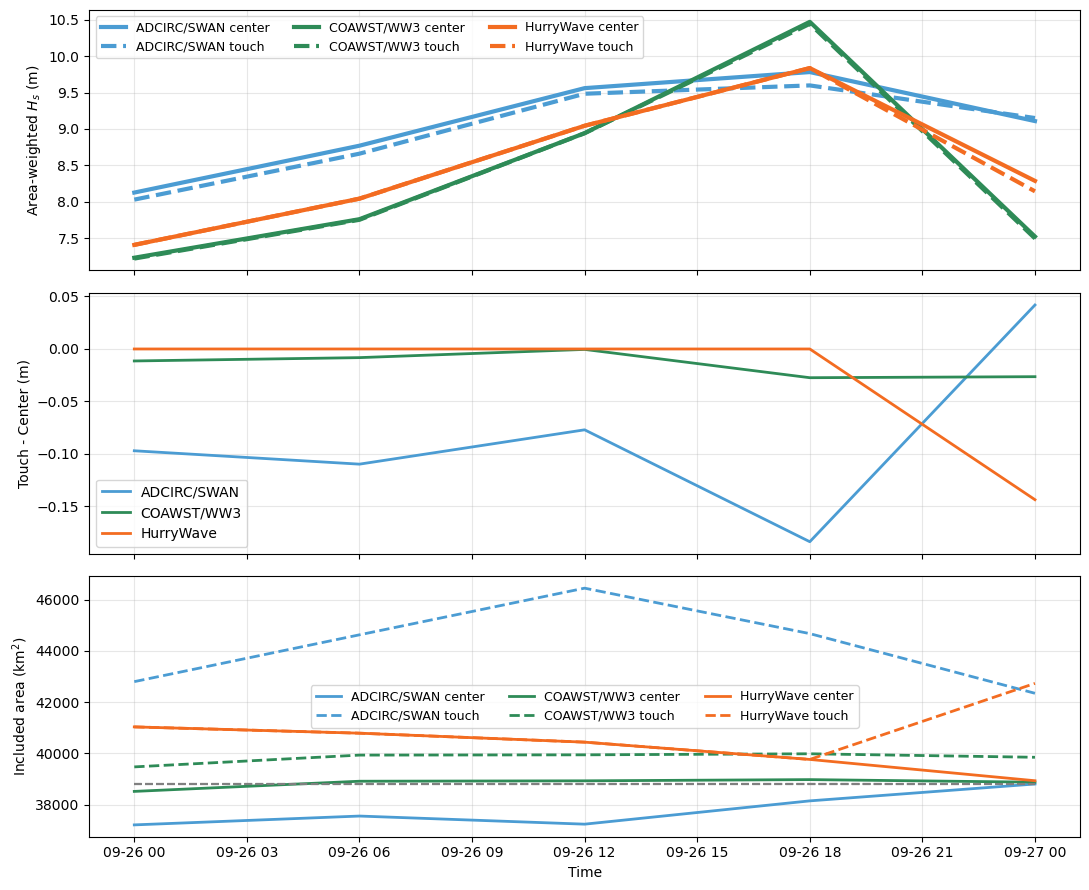

In [51]:
def plot_square_comparison(ds_cmp, figsize=(11, 9)):
    x = pd.to_datetime(ds_cmp["time"].values)

    # compute nominal area
    radius_nm = ds_cmp.attrs['radius_nm']
    area_km2 = 38793

    dutch_orange = '#F36C21'
    unc_blue = '#4B9CD3'
    usgs_green = '#2E8B57'

    colors = [ unc_blue, usgs_green, dutch_orange ]

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)

    for i, model in enumerate(ds_cmp["model"].values):
        axes[0].plot(x, ds_cmp["hs_area_mean_center"].sel(model=model), lw=3, color=colors[i], label=f"{model} center")
        axes[0].plot(x, ds_cmp["hs_area_mean_touch"].sel(model=model), lw=3,  color=colors[i], linestyle="--", label=f"{model} touch")
        axes[1].plot( 
            x,
            ds_cmp["hs_area_mean_touch"].sel(model=model) - ds_cmp["hs_area_mean_center"].sel(model=model), lw=2,  color=colors[i],
            label=str(model)
        )
        axes[2].plot( [x[0],x[-1]], [area_km2, area_km2], '--', c='gray')
        axes[2].plot(x, ds_cmp["area_sum_m2_center"].sel(model=model) / 1e6, lw=2, color=colors[i], label=f"{model} center")
        axes[2].plot(x, ds_cmp["area_sum_m2_touch"].sel(model=model) / 1e6, lw=2, color=colors[i], linestyle="--", label=f"{model} touch")

    axes[0].set_ylabel("Area-weighted $H_s$ (m)")
    axes[1].set_ylabel("Touch - Center (m)")
    axes[2].set_ylabel("Included area (km$^2$)")
    axes[2].set_xlabel("Time")

    for ax in axes:
        ax.grid(True, alpha=0.3)

    axes[0].legend(ncol=3, fontsize=9)
    axes[1].legend()
    axes[2].legend(ncol=3, fontsize=9)

    plt.tight_layout()
    return fig, axes
fig, axes = plot_square_comparison(ds_cmp)

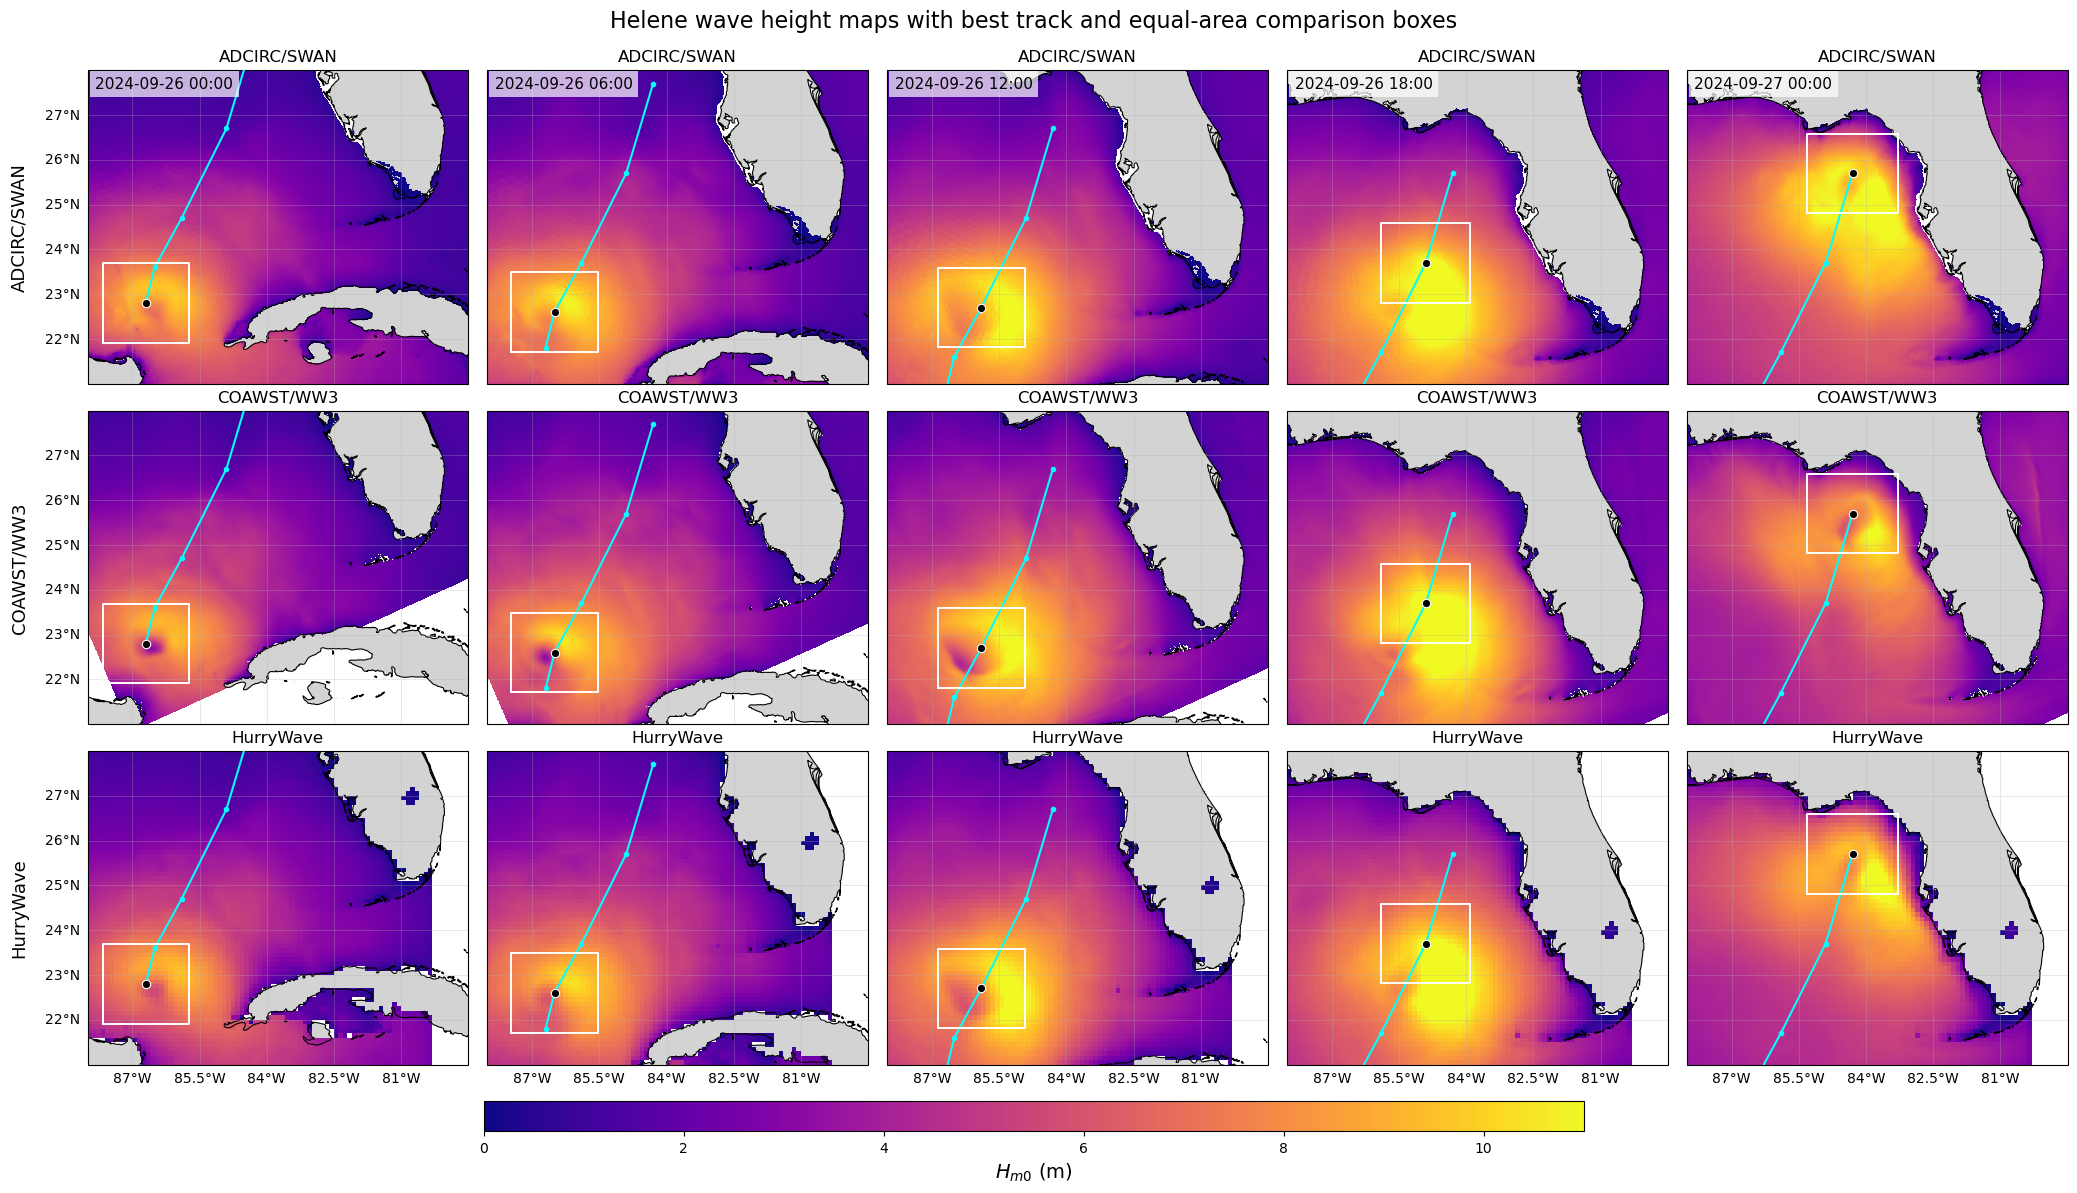

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.tri as mtri

# ============================================================
# CONSTANTS
# ============================================================
EARTH_RADIUS_M = 6371000.0
NM_TO_M = 1852.0

# ============================================================
# USER SETTINGS
# ============================================================
lon_min, lon_max = -88.0, -79.5
lat_min, lat_max = 24.0, 31.0
extent_default = [lon_min, lon_max, lat_min, lat_max]

cmap = "plasma"
vmin = 0.0
vmax = 11.0

outfile = "F:/crs/proj/2025_NOPP_comparison/helene_figs/fifteen_panel_Hm0_track_box.png"

radius_nm = 60.0


# ============================================================
# TIME / TRACK HELPERS
# ============================================================
def fix_adcirc_year_2022_to_2024(time_in):
    t = pd.to_datetime(time_in)
    t_fixed = []
    for tt in t:
        if pd.isna(tt):
            t_fixed.append(pd.NaT)
        elif tt.year == 2022:
            t_fixed.append(tt.replace(year=2024))
        else:
            t_fixed.append(tt)
    return pd.to_datetime(t_fixed)


def build_helene_best_track():
    rows = [
        ("HELENE", "2024-09-26 00:00", 22.8, -86.7),
        ("HELENE", "2024-09-26 06:00", 23.6, -86.5),
        ("HELENE", "2024-09-26 12:00", 24.7, -85.9),
        ("HELENE", "2024-09-26 18:00", 26.7, -84.9),
        ("HELENE", "2024-09-27 00:00", 28.7, -84.3),
    ]
    df = pd.DataFrame(rows, columns=["stormname", "time", "lat", "lon"])
    df["time"] = pd.to_datetime(df["time"])
    return df


def exact_time_index(time_vals, target_time):
    time_vals = pd.to_datetime(time_vals)
    target_time = pd.Timestamp(target_time)
    matches = np.where(time_vals == target_time)[0]
    if len(matches) == 0:
        return None
    return int(matches[0])


# ============================================================
# GEOMETRY HELPERS
# ============================================================
def square_side_from_radius_nm(radius_nm):
    r_m = radius_nm * NM_TO_M
    return np.sqrt(np.pi) * r_m


def square_lonlat_from_center(center_lon, center_lat, side_m):
    """
    Return closed polygon (lon, lat) for equal-area square centered at
    center_lon, center_lat using local metric conversion.
    """
    half = 0.5 * side_m

    dx = np.array([-half, half, half, -half, -half])
    dy = np.array([-half, -half, half, half, -half])

    lat0_rad = np.deg2rad(center_lat)

    dlat = np.rad2deg(dy / EARTH_RADIUS_M)
    dlon = np.rad2deg(dx / (EARTH_RADIUS_M * np.cos(lat0_rad)))

    lon = center_lon + dlon
    lat = center_lat + dlat
    return lon, lat


def adjusted_extent_for_time(panel_time, bt, extent_default, radius_nm=60.0):
    """
    For the first three best-track times only, if the bottom of the
    measurement square is south of the default lat_min, reset the southern
    boundary to floor(box_bottom_lat) and preserve the total latitude span.

    After 2024-09-26 12:00, keep the default extent.
    """
    panel_time = pd.Timestamp(panel_time)
    trigger_end = pd.Timestamp("2024-09-26 12:00")

    lon_min, lon_max, lat_min, lat_max = extent_default
    lat_span = lat_max - lat_min

    if panel_time > trigger_end:
        return extent_default

    row = bt.loc[bt["time"] == panel_time].iloc[0]
    clon = float(row["lon"])
    clat = float(row["lat"])

    side_m = square_side_from_radius_nm(radius_nm)
    box_lon, box_lat = square_lonlat_from_center(clon, clat, side_m)
    box_bottom = np.min(box_lat)

    if box_bottom < lat_min:
        new_lat_min = np.floor(box_bottom)
        new_lat_max = new_lat_min + lat_span
        return [lon_min, lon_max, new_lat_min, new_lat_max]

    return extent_default


# ============================================================
# MAP STYLE
# ============================================================
def _set_map_style(ax, extent=None, show_left_labels=True, show_bottom_labels=True):
    ax.coastlines(resolution="10m", linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = show_left_labels
    gl.bottom_labels = show_bottom_labels

    if extent is not None:
        ax.set_extent(extent, crs=ccrs.PlateCarree())


def _get_ax(fig, nrows, ncols, index):
    return fig.add_subplot(nrows, ncols, index, projection=ccrs.PlateCarree())


# ============================================================
# MODEL-SPECIFIC DATA PREP
# ============================================================
def build_hurrywave_plot_dict(ds_hw, it):
    return {
        "name": "HurryWave",
        "corner_x": ds_hw["corner_x"].values,
        "corner_y": ds_hw["corner_y"].values,
        "z": ds_hw["hm0"].isel(time=it).values,
    }


def build_adcirc_plot_dict(ds_adc, it):
    tri = ds_adc["element"].values.astype(int)
    start_index = ds_adc["element"].attrs.get("start_index", None)
    if start_index == 1 or tri.min() == 1:
        tri = tri - 1

    triang = mtri.Triangulation(
        ds_adc["x"].values,
        ds_adc["y"].values,
        triangles=tri,
    )

    return {
        "name": "ADCIRC/SWAN",
        "tri": triang,
        "z": ds_adc["swan_HS"].isel(time=it).values,
    }


def build_coawst_plot_dict(ds_cw, it):
    z = ds_cw["Hwave"].isel(ocean_time=it).values

    if "wetdry_mask_rho" in ds_cw:
        wet = ds_cw["wetdry_mask_rho"].isel(ocean_time=it).values > 0
        z = np.where(wet, z, np.nan)

    if "mask_rho" in ds_cw:
        mask_rho = ds_cw["mask_rho"].values > 0
        z = np.where(mask_rho, z, np.nan)

    return {
        "name": "COAWST/WW3",
        "x": ds_cw["lon_rho"].values,
        "y": ds_cw["lat_rho"].values,
        "z": z,
    }


# ============================================================
# MODEL-SPECIFIC PANEL PLOTTING
# ============================================================
def plot_coawst_panel(ax, d, vmin, vmax, cmap, extent, show_left_labels=True, show_bottom_labels=True):
    pcm = ax.pcolormesh(
        d["x"], d["y"], d["z"],
        cmap=cmap, vmin=vmin, vmax=vmax,
        shading="auto",
        transform=ccrs.PlateCarree(),
    )

    _set_map_style(ax, extent=extent, show_left_labels=show_left_labels, show_bottom_labels=show_bottom_labels)
    ax.set_title(f'{d["name"]}', fontsize=12)
    return pcm


def plot_adcirc_panel(ax, d, vmin, vmax, cmap, extent, show_left_labels=True, show_bottom_labels=True):
    pcm = ax.tripcolor(
        d["tri"], d["z"],
        shading="flat",
        cmap=cmap, vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree(),
    )

    _set_map_style(ax, extent=extent, show_left_labels=show_left_labels, show_bottom_labels=show_bottom_labels)
    ax.set_title(f'{d["name"]}', fontsize=12)
    return pcm


def plot_hurrywave_panel(ax, d, vmin, vmax, cmap, extent, show_left_labels=True, show_bottom_labels=True):
    pcm = ax.pcolormesh(
        d["corner_x"], d["corner_y"], d["z"],
        cmap=cmap, vmin=vmin, vmax=vmax,
        shading="flat",
        transform=ccrs.PlateCarree(),
    )

    _set_map_style(ax, extent=extent, show_left_labels=show_left_labels, show_bottom_labels=show_bottom_labels)
    ax.set_title(f'{d["name"]}', fontsize=12)
    return pcm


# ============================================================
# OVERLAYS
# ============================================================
def add_track_and_box(
    ax,
    bt,
    panel_time,
    radius_nm=60.0,
    track_color="cyan",
    box_color="white",
    point_color="black",
):
    ax.plot(
        bt["lon"].values,
        bt["lat"].values,
        color=track_color,
        linewidth=1.5,
        marker="o",
        markersize=3,
        transform=ccrs.PlateCarree(),
        zorder=20,
    )

    row = bt.loc[bt["time"] == pd.Timestamp(panel_time)].iloc[0]
    clon = float(row["lon"])
    clat = float(row["lat"])

    ax.plot(
        clon, clat,
        marker="o",
        markersize=6,
        color=point_color,
        markeredgecolor="white",
        markeredgewidth=0.8,
        transform=ccrs.PlateCarree(),
        zorder=21,
    )

    side_m = square_side_from_radius_nm(radius_nm)
    box_lon, box_lat = square_lonlat_from_center(clon, clat, side_m)

    ax.plot(
        box_lon, box_lat,
        color=box_color,
        linewidth=1.4,
        transform=ccrs.PlateCarree(),
        zorder=20,
    )


def add_missing_label(ax, model_name, panel_time):
    ax.text(
        0.5, 0.55,
        f"{model_name}\nno output at\n{pd.Timestamp(panel_time):%Y-%m-%d %H:%M}",
        ha="center", va="center",
        transform=ax.transAxes,
        fontsize=11,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="0.3"),
        zorder=30,
    )


# ============================================================
# MAIN 15-PANEL PLOT
# ============================================================
def plot_fifteen_panel_hm0_with_track_and_boxes(
    ds_hw,
    ds_adc,
    ds_cw,
    radius_nm=60.0,
    extent_default=None,
    cmap="plasma",
    vmin=0.0,
    vmax=11.0,
    outfile=None,
):
    """
    Make a 15-panel figure:
      rows = models (ADCIRC/SWAN, COAWST/WW3, HurryWave)
      cols = best-track times
    """
    bt = build_helene_best_track()

    time_hw = pd.to_datetime(ds_hw["time"].values)
    time_adc = fix_adcirc_year_2022_to_2024(ds_adc["time"].values)
    time_cw = pd.to_datetime(ds_cw["ocean_time"].values)

    fig = plt.figure(figsize=(22, 12))
    pcm_ref = None

    row_labels = ["ADCIRC/SWAN", "COAWST/WW3", "HurryWave"]

    for col, panel_time in enumerate(bt["time"].values, start=1):
        panel_time = pd.Timestamp(panel_time)
        extent_this = adjusted_extent_for_time(
            panel_time=panel_time,
            bt=bt,
            extent_default=extent_default,
            radius_nm=radius_nm,
        )

        show_left = (col == 1)

        # ----------------------------------------------------
        # Row 1: ADCIRC/SWAN
        # ----------------------------------------------------
        ax = _get_ax(fig, 3, 5, col)
        it = exact_time_index(time_adc, panel_time)
        show_bottom = False

        _set_map_style(ax, extent=extent_this, show_left_labels=show_left, show_bottom_labels=show_bottom)

        if it is None:
            add_missing_label(ax, "ADCIRC/SWAN", panel_time)
        else:
            d_ad = build_adcirc_plot_dict(ds_adc, it)
            pcm = ax.tripcolor(
                d_ad["tri"], d_ad["z"],
                shading="flat",
                cmap=cmap, vmin=vmin, vmax=vmax,
                transform=ccrs.PlateCarree(),
            )
            if pcm_ref is None:
                pcm_ref = pcm
            ax.set_title("ADCIRC/SWAN", fontsize=12)
            add_track_and_box(ax, bt, panel_time, radius_nm=radius_nm)

        ax.text(
            0.02, 0.98,
            f"{panel_time:%Y-%m-%d %H:%M}",
            ha="left", va="top",
            transform=ax.transAxes,
            fontsize=11,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
            zorder=30,
        )

        if col == 1:
            ax.text(
                -0.18, 0.5, row_labels[0],
                rotation=90, va="center", ha="center",
                transform=ax.transAxes, fontsize=13
            )

        # ----------------------------------------------------
        # Row 2: COAWST/WW3
        # ----------------------------------------------------
        ax = _get_ax(fig, 3, 5, 5 + col)
        it = exact_time_index(time_cw, panel_time)
        show_bottom = False

        _set_map_style(ax, extent=extent_this, show_left_labels=show_left, show_bottom_labels=show_bottom)

        if it is None:
            add_missing_label(ax, "COAWST/WW3", panel_time)
        else:
            d_cw = build_coawst_plot_dict(ds_cw, it)
            pcm = ax.pcolormesh(
                d_cw["x"], d_cw["y"], d_cw["z"],
                cmap=cmap, vmin=vmin, vmax=vmax,
                shading="auto",
                transform=ccrs.PlateCarree(),
            )
            if pcm_ref is None:
                pcm_ref = pcm
            ax.set_title("COAWST/WW3", fontsize=12)
            add_track_and_box(ax, bt, panel_time, radius_nm=radius_nm)

        if col == 1:
            ax.text(
                -0.18, 0.5, row_labels[1],
                rotation=90, va="center", ha="center",
                transform=ax.transAxes, fontsize=13
            )

        # ----------------------------------------------------
        # Row 3: HurryWave
        # ----------------------------------------------------
        ax = _get_ax(fig, 3, 5, 10 + col)
        it = exact_time_index(time_hw, panel_time)
        show_bottom = True

        _set_map_style(ax, extent=extent_this, show_left_labels=show_left, show_bottom_labels=show_bottom)

        if it is None:
            add_missing_label(ax, "HurryWave", panel_time)
        else:
            d_hw = build_hurrywave_plot_dict(ds_hw, it)
            pcm = ax.pcolormesh(
                d_hw["corner_x"], d_hw["corner_y"], d_hw["z"],
                cmap=cmap, vmin=vmin, vmax=vmax,
                shading="flat",
                transform=ccrs.PlateCarree(),
            )
            if pcm_ref is None:
                pcm_ref = pcm
            ax.set_title("HurryWave", fontsize=12)
            add_track_and_box(ax, bt, panel_time, radius_nm=radius_nm)

        if col == 1:
            ax.text(
                -0.18, 0.5, row_labels[2],
                rotation=90, va="center", ha="center",
                transform=ax.transAxes, fontsize=13
            )

    fig.subplots_adjust(bottom=0.10, top=0.93, left=0.07, right=0.97, wspace=0.05, hspace=0.08)

    cbar_ax = fig.add_axes([0.25, 0.045, 0.50, 0.025])
    cbar = fig.colorbar(pcm_ref, cax=cbar_ax, orientation="horizontal")
    cbar.set_label("$H_{m0}$ (m)", fontsize=14)
    cbar.ax.xaxis.set_label_position("bottom")
    cbar.ax.xaxis.set_ticks_position("bottom")

    fig.suptitle(
        "Helene wave height maps with best track and equal-area comparison boxes",
        fontsize=16,
        y=0.98,
    )

    if outfile is not None:
        plt.savefig(outfile, dpi=300, bbox_inches="tight")

    plt.show()
    return fig


# ============================================================
# RUN
# ============================================================
fig = plot_fifteen_panel_hm0_with_track_and_boxes(
    ds_hw=ds_hw,
    ds_adc=ds_adc,
    ds_cw=ds_cw,
    radius_nm=60.0,
    extent_default=extent_default,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    outfile=outfile,
)